# Lab 6 — Segmentation Summary

**Day 05 · Unsupervised Learning · Cisco AI/ML Training**

---

Translate cluster IDs into segment-level analytics and business narrative.

**Dataset:** `data/nyse/nyse_stocks.csv` (500 rows, 25 symbols)

## Setup and final segmentation assignment

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

FEATURE_COLUMNS = ["avg_close", "volatility", "avg_volume", "avg_range"]

nyse = pd.read_csv(GH_ROOT / "data" / "nyse" / "nyse_stocks.csv", parse_dates=["date"])
nyse["range"] = nyse["high"] - nyse["low"]
features = (
    nyse.groupby("symbol")
    .agg(
        avg_close=("close", "mean"),
        volatility=("close", "std"),
        avg_volume=("volume", "mean"),
        avg_range=("range", "mean"),
    )
    .reset_index()
)
features["volatility"] = features["volatility"].fillna(0.0)

X_scaled = StandardScaler().fit_transform(features[FEATURE_COLUMNS])

k = 4
features = features.copy()
features["segment"] = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)

print("Lab 6 — Segmentation summary")
print(f"segments (k): {k}")


Lab 6 — Segmentation summary
segments (k): 4


## Segment size counts

In [2]:
segment_sizes = features["segment"].value_counts().sort_index()
segment_sizes_dict = segment_sizes.to_dict()

print(f"symbols per segment: {segment_sizes_dict}")
display(segment_sizes.rename("count").to_frame())


symbols per segment: {0: 8, 1: 9, 2: 7, 3: 1}


,count
segment,
0,8
1,9
2,7
3,1


## Segment feature means

In [3]:
summary = (
    features.groupby("segment")[FEATURE_COLUMNS]
    .mean()
    .round(2)
    .reset_index()
)

print("segment means:")
display(summary)


segment means:


,segment,avg_close,volatility,avg_volume,avg_range
0,0,203.03,2.72,23941634.18,3.04
1,1,113.49,2.32,26739334.61,2.70
2,2,81.54,2.88,25411128.95,2.93
3,3,232.55,1.63,19338890.65,2.58


## Sample symbols per segment

In [4]:
print("sample symbols per segment:")
sample_rows = []
for seg in sorted(features["segment"].unique()):
    symbols = features.loc[features["segment"] == seg, "symbol"].head(4).tolist()
    print(f"  segment {seg}: {symbols}")
    sample_rows.append({"segment": seg, "sample_symbols": ", ".join(symbols)})

display(pd.DataFrame(sample_rows))


sample symbols per segment:
  segment 0: ['CSCO', 'DIS', 'MSFT', 'NFLX']
  segment 1: ['AAPL', 'AMZN', 'BAC', 'HD']
  segment 2: ['GOOGL', 'JNJ', 'JPM', 'META']
  segment 3: ['PEP']


,segment,sample_symbols
0,0,"CSCO, DIS, MSFT, NFLX"
1,1,"AAPL, AMZN, BAC, HD"
2,2,"GOOGL, JNJ, JPM, META"
3,3,PEP


## Human-readable segment labels

In [5]:
labels = {
    0: "high price / large-cap growth",
    1: "mid price / diversified large names",
    2: "lower price / higher volatility",
    3: "singleton — high price, low vol (PEP)",
}

summary_labeled = summary.copy()
summary_labeled["label"] = summary_labeled["segment"].map(labels)
display(summary_labeled)


,segment,avg_close,volatility,avg_volume,avg_range,label
0,0,203.03,2.72,23941634.18,3.04,high price / large-cap growth
1,1,113.49,2.32,26739334.61,2.70,mid price / diversified large names
2,2,81.54,2.88,25411128.95,2.93,lower price / higher volatility
3,3,232.55,1.63,19338890.65,2.58,"singleton — high price, low vol (PEP)"


## Symbol-level segment table

In [6]:
display(
    features[["symbol", "segment", "avg_close", "volatility"]]
    .sort_values(["segment", "symbol"])
    .round(2)
)


,symbol,segment,avg_close,volatility
3,CSCO,0,164.62,2.53
4,DIS,0,203.29,2.49
13,MSFT,0,215.09,3.11
14,NFLX,0,220.97,2.68
15,NVDA,0,171.25,2.49
19,TSLA,0,230.07,2.86
21,V,0,247.82,2.81
22,VZ,0,171.15,2.78
0,AAPL,1,186.88,2.23
1,AMZN,1,52.76,2.61


## Segment size bar chart

C:\Users\PC\AppData\Local\Temp\ipykernel_27056\3806178753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


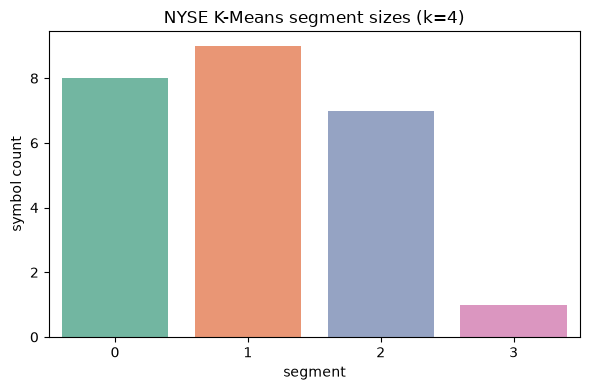

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    x=segment_sizes.index.astype(str),
    y=segment_sizes.values,
    ax=ax,
    palette="Set2",
)
ax.set_xlabel("segment")
ax.set_ylabel("symbol count")
ax.set_title("NYSE K-Means segment sizes (k=4)")
plt.tight_layout()
plt.show()


## Day recap table

In [8]:
recap = pd.DataFrame({
    "lab": [
        "1 K-Means",
        "2 Elbow",
        "3 DBSCAN",
        "4 Metrics",
        "5 Multi-view",
        "6 Summary",
    ],
    "checkpoint": [
        "inertia ≈ 45.86",
        "best k = 3",
        "3 clusters, 11 noise",
        "silhouette ≈ 0.24",
        "multi_cluster_view.png",
        str(segment_sizes_dict),
    ],
})
display(recap)


,lab,checkpoint
0,1 K-Means,inertia ≈ 45.86
1,2 Elbow,best k = 3
2,3 DBSCAN,"3 clusters, 11 noise"
3,4 Metrics,silhouette ≈ 0.24
4,5 Multi-view,multi_cluster_view.png
5,6 Summary,"{0: 8, 1: 9, 2: 7, 3: 1}"


### Segmentation prompt 1

Sort segments by avg_close descending.

In [9]:
display(summary.sort_values('avg_close', ascending=False))

,segment,avg_close,volatility,avg_volume,avg_range
3,3,232.55,1.63,19338890.65,2.58
0,0,203.03,2.72,23941634.18,3.04
1,1,113.49,2.32,26739334.61,2.70
2,2,81.54,2.88,25411128.95,2.93


### Segmentation prompt 2

Sort segments by volatility descending.

In [10]:
display(summary.sort_values('volatility', ascending=False))

,segment,avg_close,volatility,avg_volume,avg_range
2,2,81.54,2.88,25411128.95,2.93
0,0,203.03,2.72,23941634.18,3.04
1,1,113.49,2.32,26739334.61,2.70
3,3,232.55,1.63,19338890.65,2.58


### Segmentation prompt 3

Compute spread between highest and lowest avg_close segment.

In [11]:
print(round(summary['avg_close'].max() - summary['avg_close'].min(), 2))

151.01


### Segmentation prompt 4

List symbols in segment 0.

In [12]:
print(features.loc[features['segment']==0, 'symbol'].tolist())

['CSCO', 'DIS', 'MSFT', 'NFLX', 'NVDA', 'TSLA', 'V', 'VZ']


### Segmentation prompt 5

List symbols in segment 1.

In [13]:
print(features.loc[features['segment']==1, 'symbol'].tolist())

['AAPL', 'AMZN', 'BAC', 'HD', 'INTC', 'KO', 'MA', 'PG', 'WMT']


### Segmentation prompt 6

List symbols in segment 2.

In [14]:
print(features.loc[features['segment']==2, 'symbol'].tolist())

['GOOGL', 'JNJ', 'JPM', 'META', 'PFE', 'UNH', 'XOM']


### Segmentation prompt 7

List symbols in segment 3.

In [15]:
print(features.loc[features['segment']==3, 'symbol'].tolist())

['PEP']


### Segmentation prompt 8

Compute avg volume by segment.

In [16]:
display(features.groupby('segment')['avg_volume'].mean().round(2))

segment
0    23941634.18
1    26739334.61
2    25411128.95
3    19338890.65
Name: avg_volume, dtype: float64

### Segmentation prompt 9

Compute avg range by segment.

In [17]:
display(features.groupby('segment')['avg_range'].mean().round(2))

segment
0    3.04
1    2.70
2    2.93
3    2.58
Name: avg_range, dtype: float64

### Segmentation prompt 10

Display segment medians.

In [18]:
display(features.groupby('segment')[FEATURE_COLUMNS].median().round(2))

,avg_close,volatility,avg_volume,avg_range
segment,,,,
0,209.19,2.73,23503097.72,3.05
1,104.69,2.28,27207975.60,2.73
2,75.19,2.85,25849308.70,2.97
3,232.55,1.63,19338890.65,2.58


### Segmentation prompt 11

Count symbols per label text.

In [19]:
tmp = features.copy(); tmp['label']=tmp['segment'].map(labels); print(tmp['label'].value_counts().to_dict())

{'mid price / diversified large names': 9, 'high price / large-cap growth': 8, 'lower price / higher volatility': 7, 'singleton — high price, low vol (PEP)': 1}


### Segmentation prompt 12

Identify top 2 avg_close symbols in each segment.

In [20]:
display(features.sort_values(['segment','avg_close'], ascending=[True, False]).groupby('segment').head(2)[['symbol','segment','avg_close']].round(2))

,symbol,segment,avg_close
21,V,0,247.82
19,TSLA,0,230.07
0,AAPL,1,186.88
23,WMT,1,150.89
5,GOOGL,2,122.58
12,META,2,102.98
16,PEP,3,232.55


### Segmentation prompt 13

Check whether segment 3 is singleton.

In [21]:
print(int((features['segment']==3).sum()))

1


### Segmentation prompt 14

Compute z-like spread on avg_close within segment 0.

In [22]:
s0 = features.loc[features['segment']==0, 'avg_close']; print(round(float(s0.std(ddof=0)), 2))

28.95


### Segmentation prompt 15

Cross-check segment sizes dictionary.

In [23]:
print(segment_sizes_dict)

{0: 8, 1: 9, 2: 7, 3: 1}


### Segmentation prompt 16

Add narrative sentence for segment 0.

In [24]:
print('Segment 0 contains high-price large-cap names with stronger average close.')

Segment 0 contains high-price large-cap names with stronger average close.


### Segmentation prompt 17

Add narrative sentence for segment 2.

In [25]:
print('Segment 2 captures lower-priced names with relatively higher volatility.')

Segment 2 captures lower-priced names with relatively higher volatility.


### Segmentation prompt 18

Compare segment means table with labeled table.

In [26]:
display(summary_labeled[['segment','label','avg_close','volatility']])

,segment,label,avg_close,volatility
0,0,high price / large-cap growth,203.03,2.72
1,1,mid price / diversified large names,113.49,2.32
2,2,lower price / higher volatility,81.54,2.88
3,3,"singleton — high price, low vol (PEP)",232.55,1.63


### Segmentation prompt 19

Bridge to anomaly day.

In [27]:
print('Next day uses imbalance and anomaly signals where cluster outliers can help feature design.')

Next day uses imbalance and anomaly signals where cluster outliers can help feature design.


### Segmentation prompt 20

Verify symbol uniqueness.

In [28]:
print(features['symbol'].nunique(), len(features))

25 25


### Lab 6 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [29]:
print("Lab 6 recap step 1: completed")

Lab 6 recap step 1: completed


### Lab 6 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [30]:
print("Lab 6 recap step 2: completed")

Lab 6 recap step 2: completed

## Final checkpoint

In [31]:
assert k == 4
assert segment_sizes_dict == {0: 8, 1: 9, 2: 7, 3: 1}
assert summary.loc[summary["segment"] == 0, "avg_close"].iloc[0] > 200
seg0_symbols = features.loc[features["segment"] == 0, "symbol"].head(4).tolist()
assert seg0_symbols == ["CSCO", "DIS", "MSFT", "NFLX"]
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

How would you rename segments for a portfolio manager audience?